In [ ]:
import pandas as pd

train_url = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv"
test_url = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv"

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Number of intents:", train_df["category"].nunique())

Train: (10003, 2)
Test: (3080, 2)
Number of intents: 77


In [ ]:
labels = sorted(train_df["category"].unique())

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

print("Number of labels:", len(labels))

Number of labels: 77


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"].tolist(),
    train_df["category"].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=train_df["category"]
)

print("Training examples:", len(train_texts))
print("Validation examples:", len(val_texts))

Training examples: 9002
Validation examples: 1001


In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=64
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings = tokenizer(
    test_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=64
)

print("Tokenization complete")

Tokenization complete


In [ ]:
train_label_ids = [label2id[label] for label in train_labels]
val_label_ids = [label2id[label] for label in val_labels]
test_label_ids = [
    label2id[label] for label in test_df["category"]
]

In [ ]:
import torch
from torch.utils.data import Dataset

class Banking77Dataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = Banking77Dataset(
    train_encodings,
    train_label_ids
)

val_dataset = Banking77Dataset(
    val_encodings,
    val_label_ids
)

test_dataset = Banking77Dataset(
    test_encodings,
    test_label_ids
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

9002
1001
3080


In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=77,
    id2label=id2label,
    label2id=label2id
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predicted_ids = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predicted_ids)
    f1 = f1_score(
        labels,
        predicted_ids,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./banking77-bert-improved",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=100,
    report_to="none",
    fp16=False
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.771664,1.507666,0.791209,0.770419
2,0.815007,0.701137,0.885115,0.883109


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.771664,1.507666,0.791209,0.770419
2,0.815007,0.701137,0.885115,0.883109
3,0.564303,0.543195,0.901099,0.899228


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=3378, training_loss=1.5227518493851095, metrics={'train_runtime': 19585.9147, 'train_samples_per_second': 1.379, 'train_steps_per_second': 0.172, 'total_flos': 888795252414720.0, 'train_loss': 1.5227518493851095, 'epoch': 3.0})

In [ ]:
test_results = trainer.evaluate(test_dataset)

print("Final Test Accuracy:", test_results["eval_accuracy"])
print("Final Test F1:", test_results["eval_f1"])

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
predictions = trainer.predict(test_dataset)

predicted_ids = np.argmax(
    predictions.predictions,
    axis=1
)

predicted_labels = [
    id2label[i]
    for i in predicted_ids
]

true_labels = test_df["category"].tolist()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    true_labels,
    predicted_labels,
    digits=4,
    zero_division=0
)

print(report)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up     0.9744    0.9500    0.9620        40
                                activate_my_card     1.0000    0.9500    0.9744        40
                                       age_limit     1.0000    1.0000    1.0000        40
                         apple_pay_or_google_pay     1.0000    1.0000    1.0000        40
                                     atm_support     0.9750    0.9750    0.9750        40
                                automatic_top_up     0.9730    0.9000    0.9351        40
         balance_not_updated_after_bank_transfer     0.7895    0.7500    0.7692        40
balance_not_updated_after_cheque_or_cash_deposit     0.9744    0.9500    0.9620        40
                         beneficiary_not_allowed     0.9487    0.9250    0.9367        40
                                 cancel_transfer     1.0000    0.9250    0.9610        40
         

In [ ]:
model_path = "/content/banking77-bert-final"
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)
print("Saved locally:", model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved locally: /content/banking77-bert-final


In [ ]:
import shutil
shutil.make_archive("/content/banking77-bert-final", "zip", "/content/banking77-bert-final")

'/content/banking77-bert-final.zip'

In [ ]:
from google.colab import files
files.download("/content/banking77-bert-final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
label_list = None

for name, val in list(globals().items()):
    if hasattr(val, "features"):
        try:
            if "label" in val.features:
                label_list = val.features["label"].names
                print(f"Found labels from '{name}'")
                break
        except Exception:
            pass

if label_list is None:
    for name, val in list(globals().items()):
        if hasattr(val, "classes_"):
            label_list = list(val.classes_)
            print(f"Found labels from '{name}'")
            break

if label_list is None and hasattr(model.config, "id2label"):
    existing = list(model.config.id2label.values())
    if existing and not str(existing[0]).startswith("LABEL_"):
        label_list = existing
        print("Found labels already in model.config")

if label_list is None:
    print("COULD NOT FIND IT -- stop here and paste me your data-loading code")
else:
    print(f"Using {len(label_list)} labels. First 5: {label_list[:5]}")

Found labels already in model.config
Using 77 labels. First 5: ['Refund_not_showing_up', 'activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support']


In [ ]:
import numpy as np

id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}
model.config.id2label = id2label
model.config.label2id = label2id

predictions = trainer.predict(test_dataset)
predicted_ids = np.argmax(predictions.predictions, axis=1)
true_ids = predictions.label_ids

predicted_labels = [id2label[i] for i in predicted_ids]
true_labels = [id2label[i] for i in true_ids]
print("Done.")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Done.


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(true_labels, predicted_labels, digits=4, zero_division=0)
print(report)

with open("/content/banking77-classification-report.txt", "w") as f:
    f.write(report)
print("Report saved!")

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up     0.9744    0.9500    0.9620        40
                                activate_my_card     1.0000    0.9500    0.9744        40
                                       age_limit     1.0000    1.0000    1.0000        40
                         apple_pay_or_google_pay     1.0000    1.0000    1.0000        40
                                     atm_support     0.9750    0.9750    0.9750        40
                                automatic_top_up     0.9730    0.9000    0.9351        40
         balance_not_updated_after_bank_transfer     0.7895    0.7500    0.7692        40
balance_not_updated_after_cheque_or_cash_deposit     0.9744    0.9500    0.9620        40
                         beneficiary_not_allowed     0.9487    0.9250    0.9367        40
                                 cancel_transfer     1.0000    0.9250    0.9610        40
         

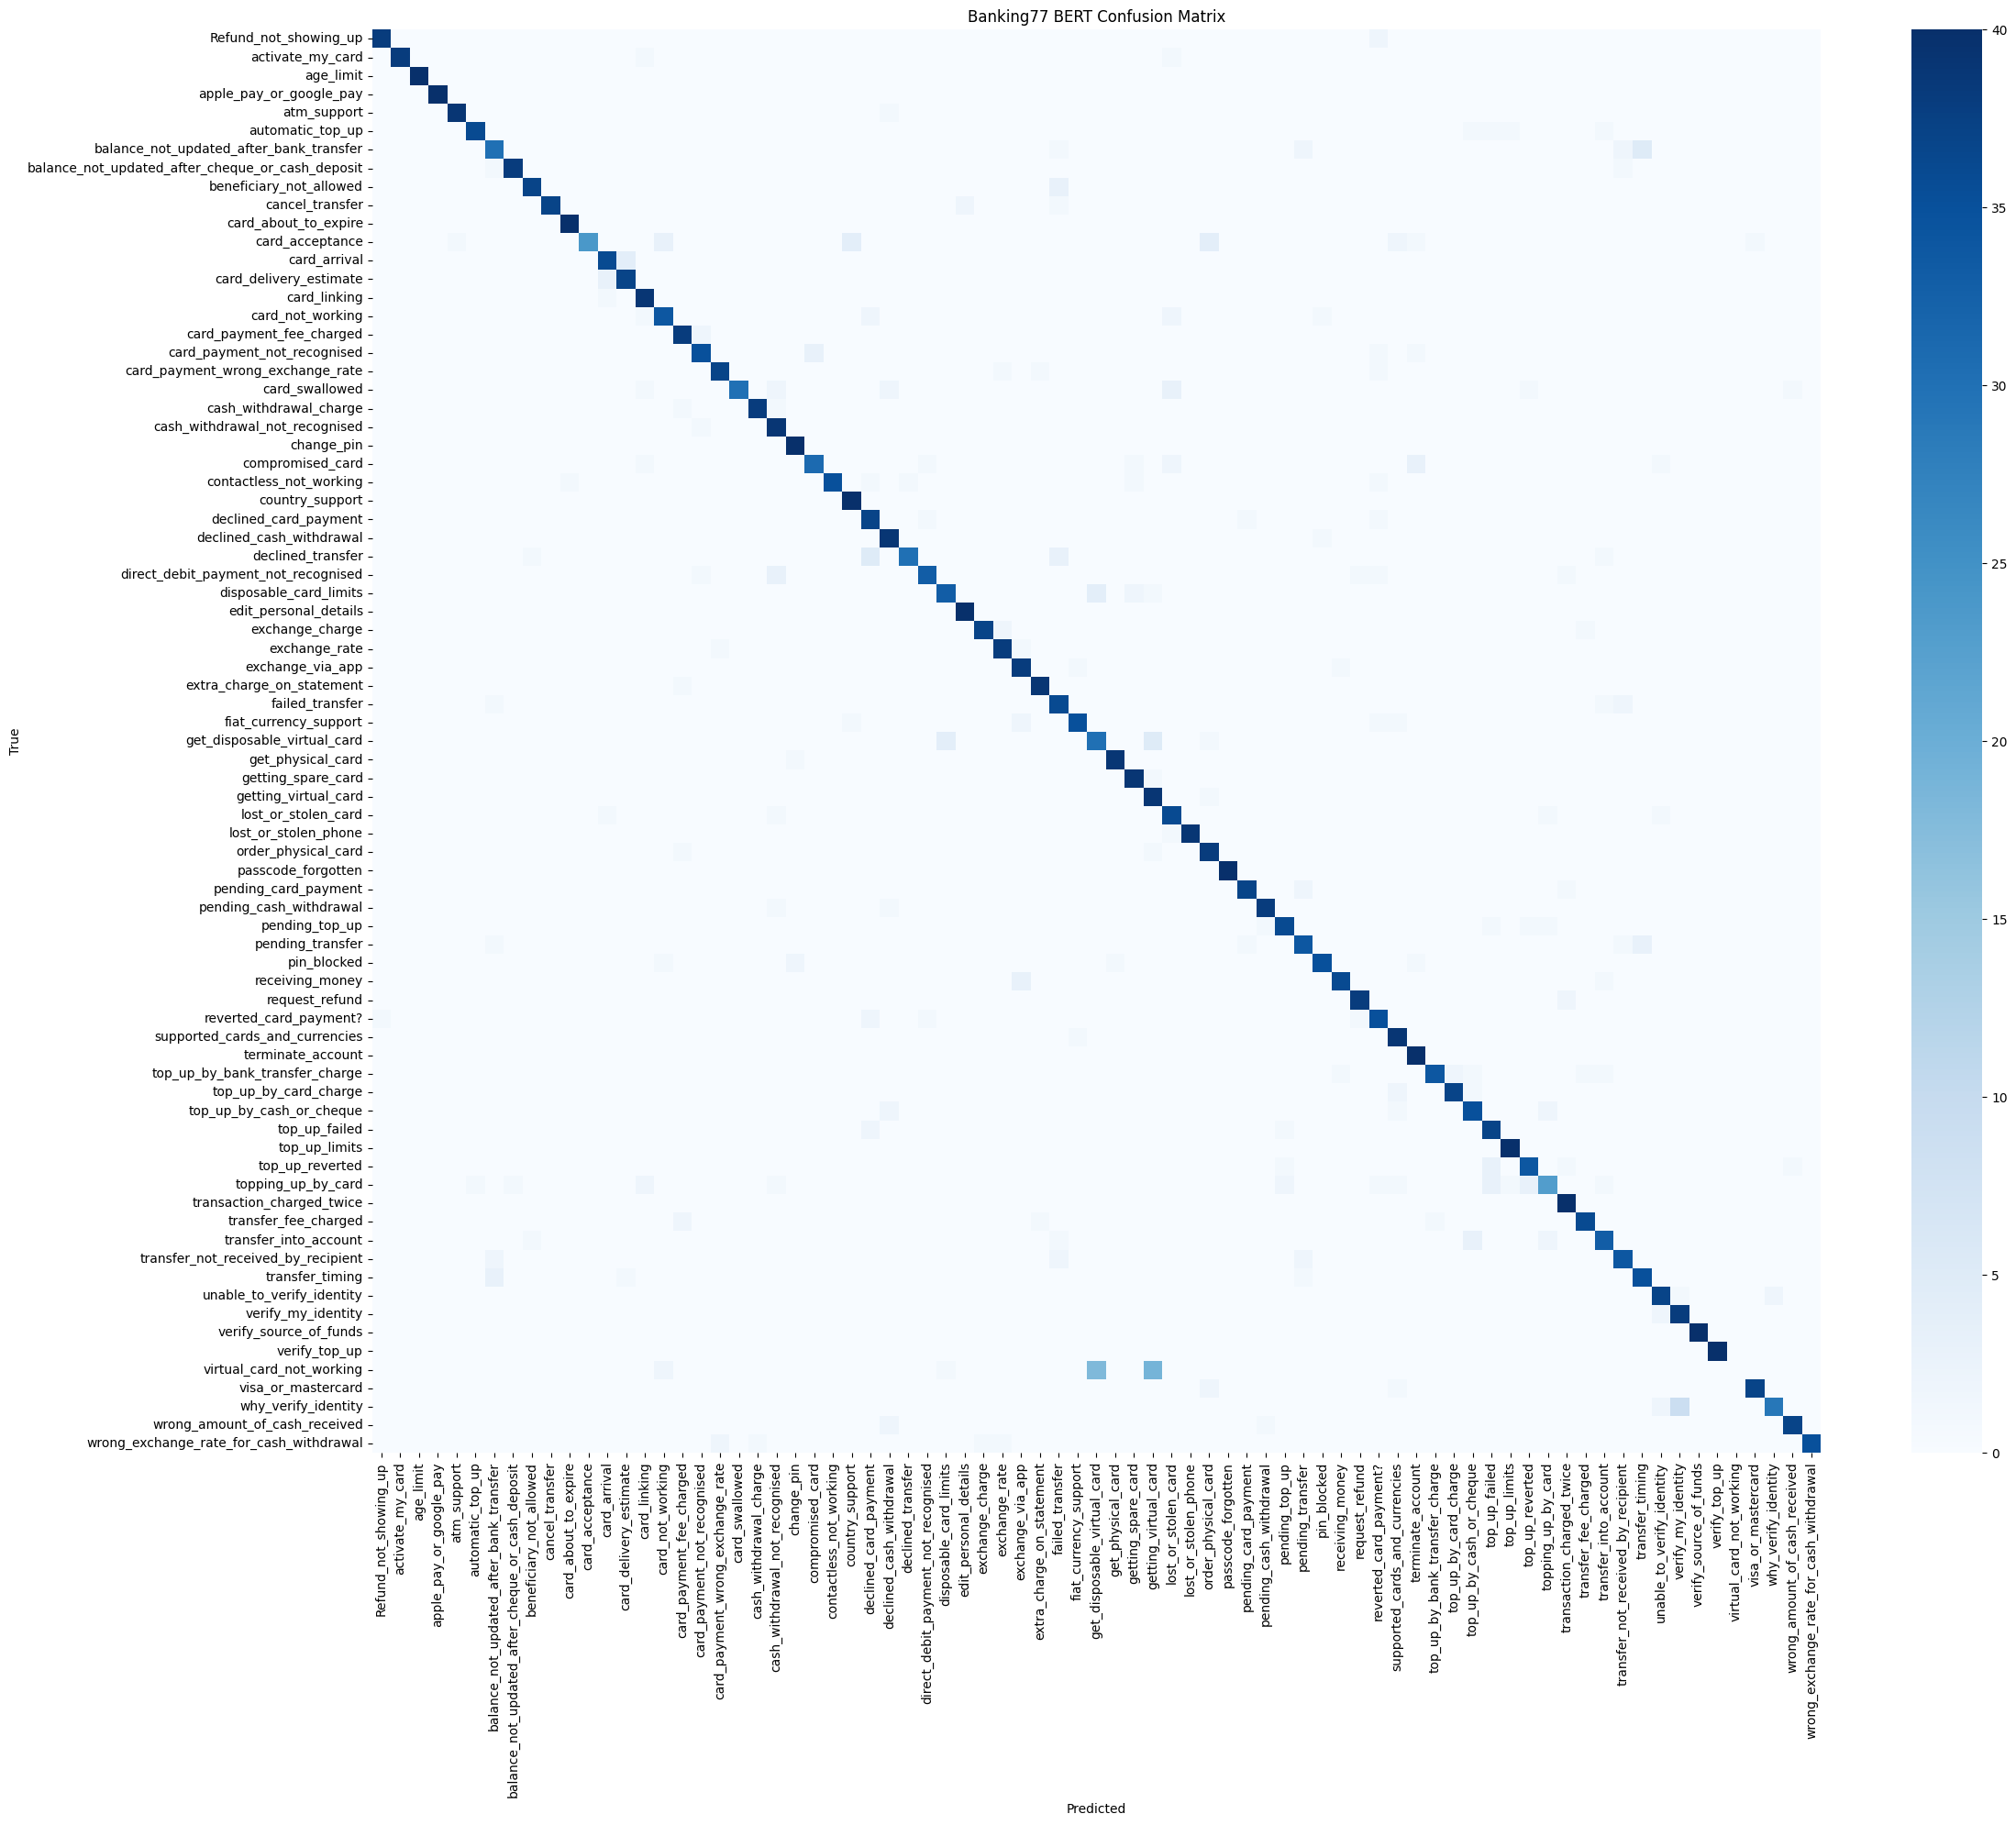

Confusion matrix saved!


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels, labels=label_list)

plt.figure(figsize=(24, 20))
sns.heatmap(cm, xticklabels=label_list, yticklabels=label_list, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Banking77 BERT Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/banking77-confusion-matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("Confusion matrix saved!")

In [ ]:
from google.colab import files
files.download("/content/banking77-classification-report.txt")
files.download("/content/banking77-confusion-matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import os

print(os.path.exists("/content/banking77-bert-final"))
print(os.listdir("/content")[:20])

False
['.config', 'sample_data']
